
# mt5-small (zh→en) — Baseline TF Training (Wuxia Domain)

**TFG Hugo Silvosa – Baseline NMT (MarianMT)**  
Este cuaderno entrena y evalúa un modelo **MarianMT** (`google/mt5-small`)  usando un dataset de **wuxia** (chino→inglés) ya preparado en formato `datasets` (HF).




## 1) Entorno de ejecución e instalación de dependencias

In [1]:

import os, random, math
import numpy as np

import torch
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Nombre de la GPU:", torch.cuda.get_device_name(0))



CUDA disponible: True
Número de GPUs: 1
Nombre de la GPU: NVIDIA GeForce RTX 3060



> **Requisitos del dataset**: directorio HF Datasets con *splits* `train`, `validation`, `test` y columnas `zh` (chino) y `en` (inglés):  
> `processed_data/wuxia_zh_en_clean/`

In [2]:
# Configuración de carpetas para entorno LOCAL
from pathlib import Path
BASE_DIR = Path.cwd().parent
BASE_DIR.mkdir(exist_ok=True)

# Estructura requerida por el usuario
for sub in ["evaluation", "models", "processed_data"]:
    (BASE_DIR / sub).mkdir(parents=True, exist_ok=True)

print("Base:", BASE_DIR.resolve())
print("Estructura creada (si no existía):")
for p in ["evaluation", "models", "proccesed data"]:
    print(" -", (BASE_DIR / p).resolve())

# Nota: el dataset debe existir en: CORPUS/proccesed data/wuxia_zh_en_clean


Base: C:\Users\Usuario\Desktop\TFG\CORPUS
Estructura creada (si no existía):
 - C:\Users\Usuario\Desktop\TFG\CORPUS\evaluation
 - C:\Users\Usuario\Desktop\TFG\CORPUS\models
 - C:\Users\Usuario\Desktop\TFG\CORPUS\proccesed data


## 2) Configuración

In [3]:
from dataclasses import dataclass

@dataclass
class Config:
    # Rutas (local)
    dataset_dir: Path  = BASE_DIR / "processed_data" / "wuxia_zh_en_clean"   
    output_dir: Path   = BASE_DIR / "models" / "mt5_small"             
    ckpt_dir: Path     = BASE_DIR / "checkpoints"
    training_dir: Path = BASE_DIR / "training"
    evaluation_dir: Path = BASE_DIR / "evaluation"

    translate_dir: Path = BASE_DIR / "evaluation" / "translate"
    translate_file: Path =  "mt5.txt"
    results_file: Path = "results.txt"
    
    # Columnas del dataset
    src_col: str = "zh"
    tgt_col: str = "en"

    # Modelo 
    model_ckpt: str = "google/mt5-small"

    # Prefijo de instrucción para T5/mT5 
    use_instruction_prefix: bool = True
    translation_prefix: str = "translate Chinese to English: "

    # Entrenamiento
    seed: int = 42
    max_source_length: int = 128
    max_target_length: int = 128
    batch_size: int = 16
    epochs: int = 10
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    early_stopping_patience: int = 3
    fraction: float = 1

cfg = Config()
print(cfg)


Config(dataset_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/processed_data/wuxia_zh_en_clean'), output_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/models/mt5_small'), ckpt_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/checkpoints'), training_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/training'), evaluation_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/evaluation'), translate_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/evaluation/translate'), translate_file='mt5.txt', results_file='results.txt', src_col='zh', tgt_col='en', model_ckpt='google/mt5-small', use_instruction_prefix=True, translation_prefix='translate Chinese to English: ', seed=42, max_source_length=128, max_target_length=128, batch_size=16, epochs=10, learning_rate=2e-05, weight_decay=0.01, early_stopping_patience=3, fraction=1)


In [4]:
import random, numpy as np, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)



# Semillas para 
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)
os.environ["PYTHONHASHSEED"] = str(cfg.seed)


if device.type == "cuda":
    torch.cuda.manual_seed_all(cfg.seed)
    # Para reproducibilidad estricta 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Semillas fijadas y backend configurado.")


Usando dispositivo: cuda
Semillas fijadas y backend configurado.


## 3) Cargar dataset (Hugging Face Datasets)

In [5]:

from datasets import load_from_disk, DatasetDict

assert os.path.isdir(cfg.dataset_dir), f"No se encuentra el dataset en: {cfg.dataset_dir}"
raw_ds: DatasetDict = load_from_disk(cfg.dataset_dir)
print(raw_ds)

# Validar columnas
def _check_cols(ds, src_col, tgt_col, split):
    cols = ds.column_names
    assert src_col in cols and tgt_col in cols, f"El split '{split}' debe contener columnas '{src_col}' y '{tgt_col}'. Columnas: {cols}"

for split in ["train", "validation", "test"]:
    assert split in raw_ds, f"Falta el split '{split}' en el dataset."
    _check_cols(raw_ds[split], cfg.src_col, cfg.tgt_col, split)

# Submuestreo 
def take_fraction(ds, frac, seed=42):
    if frac >= 1.0:
        return ds
    n = max(1, int(len(ds) * frac))
    return ds.shuffle(seed=seed).select(range(n))

train_ds = take_fraction(raw_ds["train"], cfg.fraction, seed=cfg.seed)
val_ds   = take_fraction(raw_ds["validation"], cfg.fraction, seed=cfg.seed)
test_ds  = take_fraction(raw_ds["test"], cfg.fraction, seed=cfg.seed)

print(train_ds[:2])
print(f"Tam. train/val/test (fracción={cfg.fraction}):", len(train_ds), len(val_ds), len(test_ds))


DatasetDict({
    train: Dataset({
        features: ['zh', 'en'],
        num_rows: 417208
    })
    validation: Dataset({
        features: ['zh', 'en'],
        num_rows: 52151
    })
    test: Dataset({
        features: ['zh', 'en'],
        num_rows: 52151
    })
})
{'zh': ['第章 听到白小纯的话语，看到圣皇的迟疑，邪皇这里顿时呼吸一促，他目中刹那就露出凌厉之芒，右手猛的一挥，顿时那残破的红日，骤然幻化', '尤其是看到人群内的宋缺时，神算子立刻警惕，他当年在空城，是第一个跟随白小纯的，受到了重用，如今却成为了第二个，他顿时就视宋缺为竞争对手'], 'en': ['chapter- The Saint-Emperor hesitated, and the Vile-Emperor sucked in a breath, eyes flickering with cold light as he waved his hand to summon his damaged red sun', 'That was even more the case when he noticed Song Que among Bai Xiaochun’s men, which immediately got him even more on guard. Back in Sky City, Master God-Diviner had been the first to start following Bai Xiaochun again, and it had led to incredible benefits. Now, he was only the second to join him, which put Song Que in his sights as a major rival']}
Tam. train/val/test (fracción=1): 417208 52151 52151

## 4) Tokenizer

In [6]:

from transformers import MT5Tokenizer, MT5ForConditionalGeneration

# Tokenizer
tokenizer = MT5Tokenizer.from_pretrained(cfg.model_ckpt)

# Modelo
model = MT5ForConditionalGeneration.from_pretrained(cfg.model_ckpt)

#  tokens especiales <id_0> etc
# Pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Decoder start token
if model.config.decoder_start_token_id is None:
    model.config.decoder_start_token_id = tokenizer.pad_token_id

# EOS token
if model.config.eos_token_id is None:
    model.config.eos_token_id = tokenizer.eos_token_id

model.config.use_cache = False

# Enviar a dispositivo
model.to(device)

# Info
print("Modelo:", cfg.model_ckpt)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {n_params:,}")
print("pad_token_id:", tokenizer.pad_token_id)
print("eos_token_id:", tokenizer.eos_token_id)
print("decoder_start_token_id:", model.config.decoder_start_token_id)


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'T5Tokenizer'. 
The class this function is called from is 'MT5Tokenizer'.
You are using the default legacy behaviour of the <class 'transformers.models.mt5.tokenization_mt5.MT5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


Modelo: google/mt5-small
Parámetros totales: 300,176,768
pad_token_id: 0
eos_token_id: 1
decoder_start_token_id: 0


## 5) Preprocesamiento

In [7]:

max_source_length = cfg.max_source_length
max_target_length = cfg.max_target_length

def preprocess_function(examples):
    # Source (ZH) con prefijo de instrucción para mT5
    if cfg.use_instruction_prefix:
        src_texts = [cfg.translation_prefix + s.strip() for s in examples[cfg.src_col]]
    else:
        src_texts = [s.strip() for s in examples[cfg.src_col]]

    # Target (EN)
    tgt_texts = [t.strip() for t in examples[cfg.tgt_col]]

    # 3) Tokenización: text_target=
    model_inputs = tokenizer(
        src_texts,
        max_length=max_source_length,
        truncation=True,
        padding=False
    )
    labels = tokenizer(
        text_target=tgt_texts,           # importante para que cree labels bien
        max_length=max_target_length,
        truncation=True,
        padding=False
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = raw_ds.map(
    preprocess_function,
    batched=True,
    remove_columns=raw_ds["train"].column_names
)

train_ds = take_fraction(tokenized_datasets["train"], cfg.fraction, seed=cfg.seed)
val_ds   = take_fraction(tokenized_datasets["validation"], cfg.fraction, seed=cfg.seed)
test_ds  = take_fraction(tokenized_datasets["test"], cfg.fraction, seed=cfg.seed) if "test" in tokenized_datasets else val_ds

print("Ejemplo tokenizado:", {k: type(v) for k,v in train_ds[0].items()})


Ejemplo tokenizado: {'input_ids': <class 'list'>, 'attention_mask': <class 'list'>, 'labels': <class 'list'>}


## 6) Data collator

In [8]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",
    pad_to_multiple_of=8,   # GPU
    return_tensors="pt"
)

# Ejemplo de batch
batch = data_collator([train_ds[i] for i in range(2)])
for k, v in batch.items():
    print(f"{k}: shape={v.shape}, dtype={v.dtype}")


input_ids: shape=torch.Size([2, 64]), dtype=torch.int64
attention_mask: shape=torch.Size([2, 64]), dtype=torch.int64
labels: shape=torch.Size([2, 96]), dtype=torch.int64
decoder_input_ids: shape=torch.Size([2, 96]), dtype=torch.int64


## 7) Configuración del entrenamiento


> **Por defecto**          
> **Optimizador**: `AdamW` (con LR=2e-5, weight decay=0.01) de `Seq2SeqTrainer`   
> **Loss**: `CrossEntropyLoss` (token-level) de `AutoModelForSeq2SeqLM `





In [9]:
from transformers import Seq2SeqTrainer

class MySeq2SeqTrainer(Seq2SeqTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Sobrescribe compute_loss para asegurar que siempre se usan los labels. Evita <id_0>
        Ignora argumentos extra (ej. num_items_in_batch) que el modelo no acepta.
        """
        labels = inputs.get("labels")

        # forward solo con los argumentos que mT5 acepta
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs.get("attention_mask"),
            labels=labels,
        )

        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss


In [10]:

from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

# Carpeta para resultados
run_dir = cfg.output_dir
run_dir.mkdir(parents=True, exist_ok=True)

# Argumentos de entrenamiento 
training_args = Seq2SeqTrainingArguments(
    output_dir=str(run_dir),
    overwrite_output_dir=True,
    eval_strategy="epoch",          
    save_strategy="epoch",
    save_total_limit=3,
    learning_rate=cfg.learning_rate,
    per_device_train_batch_size=cfg.batch_size,
    per_device_eval_batch_size=cfg.batch_size,
    num_train_epochs=cfg.epochs,
    weight_decay=cfg.weight_decay,
    logging_steps=200,
    predict_with_generate=True,           # <- importante para  traducción
    generation_max_length=cfg.max_target_length,
    generation_num_beams=4,
    fp16=False, #torch.cuda.is_available(), En este caso de mt5 NO se usa fp16 por razones de velocidad/optimizacion
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    max_grad_norm=1.0,
)

# Trainer para Seq2Seq
trainer = MySeq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator
)


print(" Seq2SeqTrainer configurado (PyTorch) con mT5.")


C:\Users\Usuario\AppData\Local\Temp\ipykernel_7776\2519241602.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `MySeq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = MySeq2SeqTrainer(
[codecarbon WARNING @ 17:56:09] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:56:09] [setup] RAM Tracking...
[codecarbon INFO @ 17:56:09] [setup] CPU Tracking...
[codecarbon WARNING @ 17:56:10] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 17:56:10] CPU Model on constant consumption mode: AMD Ryzen 7 5700X 8-Core Processor
[codecarbon WARNING @ 17:56:10] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 17:56:10] [setup] GPU Tracking...
[codecarbon INFO @ 17:56:10] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 17:56:10] The below tracking methods 

 Seq2SeqTrainer configurado (PyTorch) con mT5.


## 8) Cargar modelo y gráficas

In [11]:

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import gc

try:
    del model
    del tokenizer
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

best_ckpt_path = getattr(trainer.state, "best_model_checkpoint", None)
if best_ckpt_path is None:
    # Fallback: usar output_dir si no hay checkpoint
    best_ckpt_path = cfg.output_dir
    print("o se encontró 'best_model_checkpoint'. Cargando desde output_dir final.")

print(f"Cargando modelo desde: {best_ckpt_path}")

# Cargar modelo y tokenizer desde el mejor checkpoint
tokenizer = AutoTokenizer.from_pretrained(best_ckpt_path)
model = AutoModelForSeq2SeqLM.from_pretrained(best_ckpt_path).to(device)

print("Mejor modelo y tokenizer cargados.")


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'MT5Tokenizer'. 
The class this function is called from is 'T5Tokenizer'.


Usando dispositivo: cuda
o se encontró 'best_model_checkpoint'. Cargando desde output_dir final.
Cargando modelo desde: c:\Users\Usuario\Desktop\TFG\CORPUS\models\mt5_small


You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
c:\Users\Usuario\miniconda3\envs\wuxia\Lib\site-packages\transformers\convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Mejor modelo y tokenizer cargados.


 Información del entrenamiento:
  model_name: google/mt5-small
  epochs: 10
  batch_size: 16
  learning_rate: 2e-05
  weight_decay: 0.01
  train_size: 417208
  val_size: 52151
  metrics: {'train_runtime': 339640.295, 'train_samples_per_second': 12.284, 'train_steps_per_second': 0.768, 'total_flos': 2.979599022116045e+17, 'train_loss': 2.597256747914487, 'epoch': 10.0}

 Métricas finales de entrenamiento:
  epoch: 10.0
  total_flos: 2.979599022116045e+17
  train_loss: 2.597256747914487
  train_runtime: 339640.295
  train_samples_per_second: 12.284
  train_steps_per_second: 0.768

 Mejor checkpoint: c:\Users\Usuario\Desktop\TFG\CORPUS\models\pretrain_mt5_small\checkpoint-260760


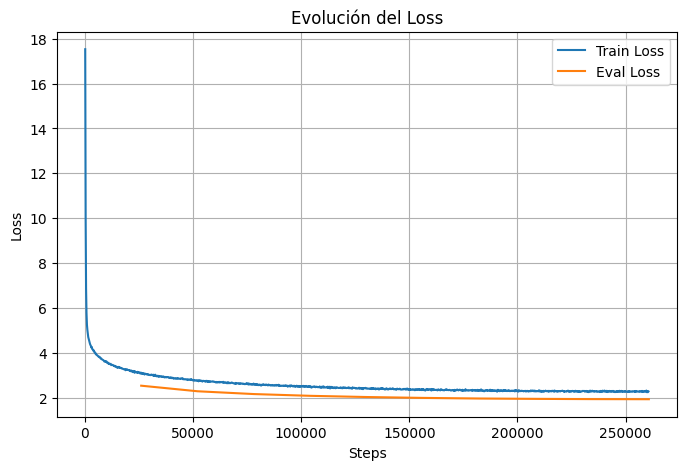

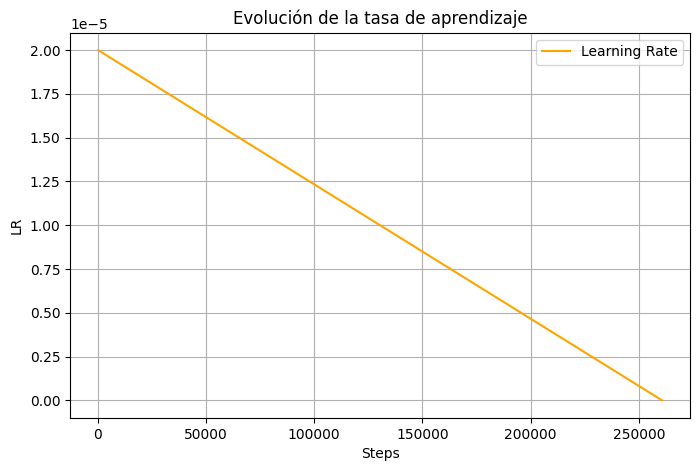

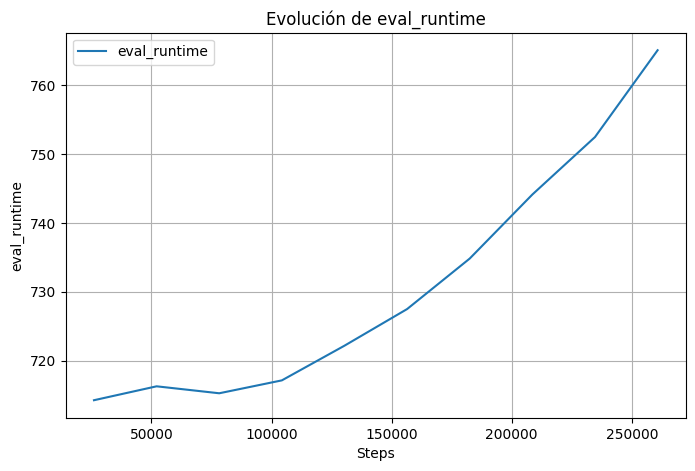

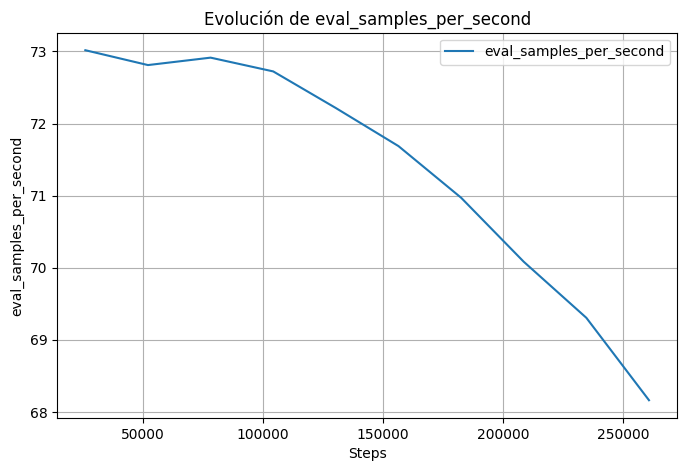

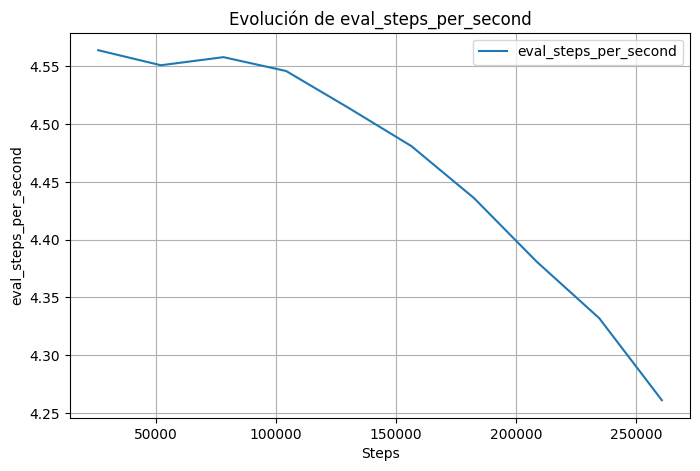

In [12]:

import json
import matplotlib.pyplot as plt
from pathlib import Path

#  info de la run 
run_info_path = Path(cfg.output_dir) / "run_info.json"
if run_info_path.exists():
    with open(run_info_path, "r", encoding="utf-8") as f:
        run_info = json.load(f)
    print(" Información del entrenamiento:")
    for k, v in run_info.items():
        print(f"  {k}: {v}")
else:
    print(f" No se encontró {run_info_path}")

#  métricas finales 
metrics_path = Path(cfg.output_dir) / "train_results.json"
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        train_metrics = json.load(f)
    print("\n Métricas finales de entrenamiento:")
    for k, v in train_metrics.items():
        print(f"  {k}: {v}")
else:
    print(f" No se encontró {metrics_path}")

# trainer_state.json para histórico de entrenamiento 
log_history_path = Path(cfg.output_dir) / "trainer_state.json"
if log_history_path.exists():
    with open(log_history_path, "r", encoding="utf-8") as f:
        trainer_state = json.load(f)

    # Info del mejor checkpoint
    best_ckpt = trainer_state.get("best_model_checkpoint", None)
    if best_ckpt:
        print(f"\n Mejor checkpoint: {best_ckpt}")
    else:
        print("\n No se encontró información del mejor checkpoint.")

    # Historial de métricas
    log_history = trainer_state.get("log_history", [])

    # Extraer métricas y pasos
    steps_train = [entry["step"] for entry in log_history if "loss" in entry]
    train_loss = [entry["loss"] for entry in log_history if "loss" in entry]

    steps_eval = [entry["step"] for entry in log_history if "eval_loss" in entry]
    eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

    learning_rates = [entry["learning_rate"] for entry in log_history if "learning_rate" in entry]
    steps_lr = [entry["step"] for entry in log_history if "learning_rate" in entry]

    # Detectar métricas adicionales
    extra_metrics = {}
    for entry in log_history:
        for k, v in entry.items():
            if k.startswith("eval_") and k not in ["eval_loss"]:
                extra_metrics.setdefault(k, {"steps": [], "values": []})
                extra_metrics[k]["steps"].append(entry["step"])
                extra_metrics[k]["values"].append(v)

    #  Gráfica loss 
    plt.figure(figsize=(8,5))
    plt.plot(steps_train, train_loss, label="Train Loss")
    plt.plot(steps_eval, eval_loss, label="Eval Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Evolución del Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    #  Gráfica learning rate 
    if learning_rates:
        plt.figure(figsize=(8,5))
        plt.plot(steps_lr, learning_rates, label="Learning Rate", color="orange")
        plt.xlabel("Steps")
        plt.ylabel("LR")
        plt.title("Evolución de la tasa de aprendizaje")
        plt.legend()
        plt.grid(True)
        plt.show()

    #  Gráficas de métricas adicionales 
    for metric_name, data in extra_metrics.items():
        plt.figure(figsize=(8,5))
        plt.plot(data["steps"], data["values"], label=metric_name)
        plt.xlabel("Steps")
        plt.ylabel(metric_name)
        plt.title(f"Evolución de {metric_name}")
        plt.legend()
        plt.grid(True)
        plt.show()

else:
    print(f"No se encontró {log_history_path}")

## 9) Evaluación (SacreBLEU, chrF, TER, ROUGE-L, METEOR)

In [13]:


from tqdm.auto import tqdm
import sacrebleu
from sacrebleu.metrics import CHRF, TER
from rouge_score import rouge_scorer
import nltk
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import wordpunct_tokenize
import numpy as np
import torch
from bert_score import score as calc_bertscore
from comet import download_model, load_from_checkpoint
import time
start = time.time()
# Descargar recursos de NLTK (para METEOR)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

#  Parámetros 
EVAL_MAX_SAMPLES = 1000        # None = todo el split
PRED_BEAMS = 4
BATCH_EVAL = max(1, cfg.batch_size // 2)

assert 'model' in globals(), "No se encontró `model`. Carga el modelo antes."
assert 'tokenizer' in globals(), "No se encontró `tokenizer`. Cárgalo antes."
assert 'val_ds' in globals() and 'test_ds' in globals(), "Faltan `val_ds` y/o `test_ds`."
assert 'cfg' in globals(), "Falta `cfg`."



# Asegurar pad_token_id
if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

# mT5: asegurar decoder_start_token_id
if getattr(model.config, 'decoder_start_token_id', None) is None and tokenizer.pad_token_id is not None:
    model.config.decoder_start_token_id = tokenizer.pad_token_id


#  Seleccionar split 
eval_raw = test_ds if len(test_ds) > 0 else val_ds
n_total = len(eval_raw)
n_eval = n_total if (EVAL_MAX_SAMPLES is None) else min(n_total, int(EVAL_MAX_SAMPLES))
assert n_eval > 0, "No hay ejemplos para evaluar."

def decode_ids_to_text(dataset, id_col):
    return [
        tokenizer.decode(ids, skip_special_tokens=True)
        for ids in dataset[id_col]
    ]

src_texts = decode_ids_to_text(eval_raw, "input_ids")[:n_eval]
ref_texts = decode_ids_to_text(eval_raw, "labels")[:n_eval]

#  mT5: asegurar prefijo de instrucción en la entrada si no lo tiene)
if hasattr(cfg, 'use_instruction_prefix') and cfg.use_instruction_prefix:
    pref = getattr(cfg, 'translation_prefix', 'translate Chinese to English: ')
    def _ensure_pref(s):
        return s if s.startswith(pref) else (pref + s)
    src_texts = [_ensure_pref(s) for s in src_texts]

#  Generación por lotes 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def batched_generate(texts, batch_size=8, max_length=128, num_beams=4):
    preds = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=cfg.max_source_length
            ).to(device)
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                num_beams=num_beams,
                early_stopping=True
            )
            preds.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
    return preds

preds = batched_generate(
    src_texts,
    batch_size=BATCH_EVAL,
    max_length=cfg.max_target_length,
    num_beams=PRED_BEAMS
)

# #  Métricas 
# bleu_corpus = sacrebleu.corpus_bleu(preds, [ref_texts]).score

# chrf_metric = CHRF(word_order=2)
# chrf_corpus = chrf_metric.corpus_score(preds, [ref_texts]).score

# ter_metric = TER()
# ter_corpus = ter_metric.corpus_score(preds, [ref_texts]).score

# def compute_rougeL_f1(hyp_list, ref_list):
#     scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
#     f1s = []
#     for h, r in zip(hyp_list, ref_list):
#         scores = scorer.score(r, h)
#         f1s.append(scores['rougeL'].fmeasure * 100.0)
#     return float(np.mean(f1s))

# rougeL_f1 = compute_rougeL_f1(preds, ref_texts)

# def compute_meteor(hyp_list, ref_list):
#     # METEOR en NLTK espera tokenización básica
#     scores = []
#     for h, r in zip(hyp_list, ref_list):
#         hyp_tok = wordpunct_tokenize(h)
#         ref_tok = wordpunct_tokenize(r)
#         scores.append(meteor_score([ref_tok], hyp_tok))
#     return float(np.mean(scores)) * 100.0

# meteor_avg = compute_meteor(preds, ref_texts)


# --- BERTSCORE ---
print("Calculando BERTScore...")
# Extraemos el idioma destino desde cfg (si no lo tienes configurado así, cámbialo por "en", "es", etc.)
tgt_language = getattr(cfg, "tgt_lang", "multilingual")
_, _, F1 = calc_bertscore(preds, ref_texts, lang=tgt_language, verbose=False)
bertscore_avg = float(F1.mean()) * 100.0

# --- COMET ---
print("Calculando COMET (puede tardar un poco en cargar la primera vez)...")
comet_model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_model_path)
comet_model.eval()

# COMET necesita el texto original (src), la predicción (mt) y la referencia (ref)
comet_data = [
    {"src": s, "mt": p, "ref": r} 
    for s, p, r in zip(src_texts, preds, ref_texts)
]
comet_output = comet_model.predict(comet_data, batch_size=BATCH_EVAL, progress_bar=True)
comet_avg = float(comet_output.system_score) * 100.0

end_time = time.time()

results = {
    "model" : getattr(cfg, "model_ckpt", "unknown_model"),
    "n_eval": n_eval,
    "num_beams": PRED_BEAMS,
    "batch_eval": BATCH_EVAL,
    # "sacrebleu": round(bleu_corpus, 4),
    # "chrf2": round(chrf_corpus, 4),
    # "ter": round(ter_corpus, 4),
    # "rougeL_f1": round(rougeL_f1, 4),
    # "meteor": round(meteor_avg, 4), 
    "bertscore": round(bertscore_avg, 4),
    "comet": round(comet_avg, 4),
    "execution_time": round(end_time - start, 2)
}

if hasattr(cfg, "evaluation_dir"):
    os.makedirs(cfg.evaluation_dir, exist_ok=True)
    res_file = os.path.join(cfg.evaluation_dir, getattr(cfg, "results_file", "results.json"))
    with open(res_file, "a", encoding="utf-8") as f:
        f.write("\n")
        f.write(json.dumps(results, ensure_ascii=False, indent=4))

print("\n--- RESULTADOS FINALES ---")
print(json.dumps(results, indent=4))


c:\Users\Usuario\miniconda3\envs\wuxia\Lib\site-packages\torchmetrics\utilities\imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


  0%|          | 0/125 [00:00<?, ?it/s]

Calculando BERTScore...
Calculando COMET (puede tardar un poco en cargar la primera vez)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Lightning automatically upgraded your loaded checkpoint from v1.8.3.post1 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\Usuario\.cache\huggingface\hub\models--Unbabel--wmt22-comet-da\snapshots\2760a223ac957f30acfb18c8aa649b01cf1d75f2\checkpoints\model.ckpt`
Encoder model frozen.
c:\Users\Usuario\miniconda3\envs\wuxia\Lib\site-packages\pytorch_lightning\core\saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to e


--- RESULTADOS FINALES ---
{
    "model": "google/mt5-small",
    "n_eval": 1000,
    "num_beams": 4,
    "batch_eval": 8,
    "bertscore": 81.3376,
    "comet": 68.9218,
    "execution_time": 194.37
}


142min

## 10) Muestra cualitativa (n ejemplos aleatorios)

In [14]:
import random
import torch

# Mostrar  aleatorias 
n_show = 100
idxs = random.sample(range(len(eval_raw)), k=min(n_show, len(eval_raw)))

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for i in idxs:
    # Decodificar texto fuente y referencia desde dataset tokenizado
    zh_in = tokenizer.decode(eval_raw[i]["input_ids"], skip_special_tokens=True)
    en_ref = tokenizer.decode(eval_raw[i]["labels"], skip_special_tokens=True)

    # Si el input ya contiene el prefijo, lo retiramos solo para imprimir "ZH:"
    if cfg.use_instruction_prefix and zh_in.startswith(cfg.translation_prefix):
        zh_print = zh_in[len(cfg.translation_prefix):]
    else:
        zh_print = zh_in

    # Preparar entrada para generate siempre con prefijo (evitar <id_0> o salidas vacias)
    zh_for_gen = cfg.translation_prefix + zh_print if cfg.use_instruction_prefix else zh_print
    inputs = tokenizer([zh_for_gen], return_tensors="pt", padding=True, truncation=True, max_length=cfg.max_source_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_length=cfg.max_target_length,
            num_beams=4,
            early_stopping=True
        )

    en_pred = tokenizer.decode(out[0], skip_special_tokens=True)

    print("="*80)
    print("ZH:", zh_print)
    print("EN (ref):", en_ref)
    print("EN (pred):", en_pred)


ZH: 最关键的是——真正的天庭,不是在这里,而是在我们的心中
EN (ref): And most importantly, the true Heavenly Court is not here, it is within our hearts
EN (pred): Most importantly — the true Heavenly Court is not here, it is in our heart
ZH: 这一切他都清楚,可他还是脚步停顿下来,没有选择离去,因为 他不能错过这个机会,一旦错过,哪怕是在这炼魂壶的世界内,他想要去找到白浩,也都极为艰难,且一旦在这过程中,白浩的魂出现了灭亡,那么将是他一生的遗憾
EN (ref): He could not pass up this oppor tunity. After all, even knowing that Bai Hao’s soul was in the Necromancer Kettle wouldn’t necessarily do much good. Even going to search for him in that one particular area would be difficult. Furthermore, if Bai Hao’s soul were to die, then Bai Xiaochun would feel regret over the matter for the rest of his life
EN (pred): However, he wasn’t going to leave. However, he had no choice but to leave. Because he couldn’t choose to leave, even in the world of the Necromancer Kettle, he would be very difficult for him to find Bai Hao. However, when he was in the world of the Necromancer Kettle, Bai Hao’s soul would be destroyed, it would 

In [15]:
# from tqdm import tqdm

# os.makedirs(cfg.translate_dir, exist_ok=True)
# translate_path = os.path.join(cfg.translate_dir, cfg.translate_file)

# with open(translate_path, "w", encoding="utf-8") as f:
#     for i in tqdm(range(len(eval_raw) // 2)):
#         zh_in = tokenizer.decode(eval_raw[i]["input_ids"], skip_special_tokens=True)
#         en_ref = tokenizer.decode(eval_raw[i]["labels"], skip_special_tokens=True)

#         # Si el input ya contiene el prefijo, lo retiramos solo para imprimir "ZH:"
#         if cfg.use_instruction_prefix and zh_in.startswith(cfg.translation_prefix):
#             zh_print = zh_in[len(cfg.translation_prefix):]
#         else:
#             zh_print = zh_in

#         # Preparar entrada para generate siempre con prefijo (evitar <id_0> o salidas vacias)
#         zh_for_gen = cfg.translation_prefix + zh_print if cfg.use_instruction_prefix else zh_print
#         inputs = tokenizer([zh_for_gen], return_tensors="pt", padding=True, truncation=True, max_length=cfg.max_source_length)
#         inputs = {k: v.to(device) for k, v in inputs.items()}

#         with torch.no_grad():
#             out = model.generate(
#                 **inputs,
#                 max_length=cfg.max_target_length,
#                 num_beams=4,
#                 early_stopping=True
#             )

#         en_pred = tokenizer.decode(out[0], skip_special_tokens=True)

#         # Guardar en el archivo
#         f.write("="*80 + "\n")
#         f.write("ZH: " + zh_in + "\n")
#         f.write("EN (ref): " + en_ref + "\n")
#         f.write("EN (pred): " + en_pred + "\n\n")


224min